In [10]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import joblib

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

DB_PATH = "/Users/darraghdonnelly/dev/Database/recovered.db"
TEST_SIZE = 0.20
RANDOM_STATE = 42

with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql_query(
        "SELECT src, sex, age, distance_m, time_s FROM concat_results",
        conn,
    )

In [11]:
# same preprocessing as the comparison notebook

df["distance_bucket"] = (
    df["distance_m"].round().astype(int)
    .map({42195: "42k", 16093: "16k", 5000: "5k"})
)
df["log_distance"] = np.log(df["distance_m"].astype(float))

feature_cols = ["log_distance", "age", "sex"]

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["distance_bucket"],
)

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_train = np.log(train_df["time_s"].astype(float))
y_test = np.log(test_df["time_s"].astype(float))


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# test selected model with optimal hps from tuning nb
model = GradientBoostingRegressor(loss='huber', learning_rate=0.1, n_estimators=400, random_state=RANDOM_STATE)

model.fit(X_train, y_train)
pred_log = model.predict(X_test)

actual_seconds = np.exp(y_test)
pred_seconds = np.exp(pred_log)

# return metrics in seconds and minutes
mae_s = mean_absolute_error(actual_seconds, pred_seconds)
rmse_s = np.sqrt(mean_squared_error(actual_seconds, pred_seconds))
r2 = r2_score(actual_seconds, pred_seconds)

print("MAE:", round(mae_s, 2), "seconds ->", round(mae_s / 60, 2), "min")
print("RMSE:", round(rmse_s, 2), "seconds ->", round(rmse_s / 60, 2), "min")
print("R2:", round(r2, 4))


MAE: 2173.29 seconds -> 36.22 min
RMSE: 3029.7 seconds -> 50.5 min
R2: 0.7268


In [13]:
# get bucketed results to get dist by dist metrics
test_eval = test_df.copy()
test_eval["pred_time_s"] = pred_seconds
test_eval["actual_time_s"] = actual_seconds.values

for bucket in ["5k", "16k", "42k"]:
    bucket_rows = test_eval[test_eval["distance_bucket"] == bucket]
    mae_seconds = mean_absolute_error(bucket_rows["actual_time_s"], bucket_rows["pred_time_s"])

    print(bucket)
    print("MAE seconds:", round(mae_seconds, 2))
    print("MAE minutes:", round(mae_seconds / 60, 2))
    print()


5k
MAE seconds: 431.63
MAE minutes: 7.19

16k
MAE seconds: 736.82
MAE minutes: 12.28

42k
MAE seconds: 2677.2
MAE minutes: 44.62



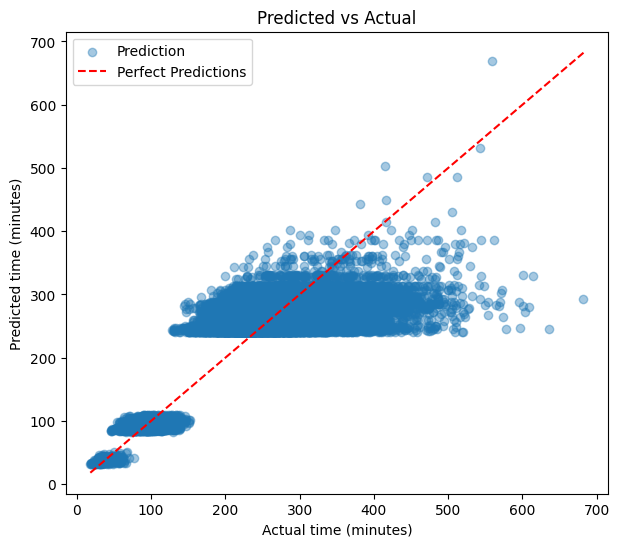

In [14]:
# predicted vs actual plot

actual_minutes = actual_seconds / 60
pred_minutes = pred_seconds / 60

plt.figure(figsize=(7, 6))
plt.scatter(actual_minutes, pred_minutes, alpha=0.4)

# plot min-max line for perfect preds
plt.plot(
    [actual_minutes.min(), actual_minutes.max()],
    [actual_minutes.min(), actual_minutes.max()],
    "r--",
)
plt.legend(["Prediction", "Perfect Predictions"])
plt.xlabel("Actual time (minutes)")
plt.ylabel("Predicted time (minutes)")
plt.title("Predicted vs Actual")
plt.show()


In [ ]:
# export model as artifact dor use
artifact = {
    "kind": "log_ridge",
    "feature_order": feature_cols,
    "model": model,
}

out_path = Path("/Users/darraghdonnelly/dev/fyp-running-app/backend/ml_models/base_model.joblib")
out_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(artifact, out_path)
print("Saved:", out_path)


Saved: /Users/darraghdonnelly/dev/fyp-running-app/backend/ml_models/base_model.joblib
